<a href="https://colab.research.google.com/github/maddygoodro/MIS433/blob/main/in_class_5_11_regression_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Basics

Regression is one of the most useful and popular functions in data mining and statistical learning.

Regression is aimed at building a **model** that can predict the value of y based on X.

There are several key concepts related to regression:
- **Prediction model**: There is a specific target variable y to predict.
- **Target variable y**: the target variable is quantitative/numerical.
- **Predictors X**: independent variables
- **Learning what?**
    - The **function** between predictors X and y.
    - F(X) -> y
- **Learning from what?**
    - **Training set**: $(X_{train}, y_{train})$
    - $X_{train}$: predictor variables of data points in the training set
    - $y_{train}$: target variable of data points in the training set
- **How accurate is the model?**
    - **Test set**: $(X_{test}, y_{test})$
    - $X_{test}$: predictor variables of data points in the test set
    - Apply the model to $X_{test}$ and output $y'_{test}$, **predicted** values.
    - $y_{test}$: **actual** values of data points in the test set, hidden from the model
    - Evaluation by comparing $y_{test}$ and $y'_{test}$
- **Evaluation metrics**:
    - $R^2$
    - Mean squared error (MSE)
    - Root mean squared error (RMSE)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

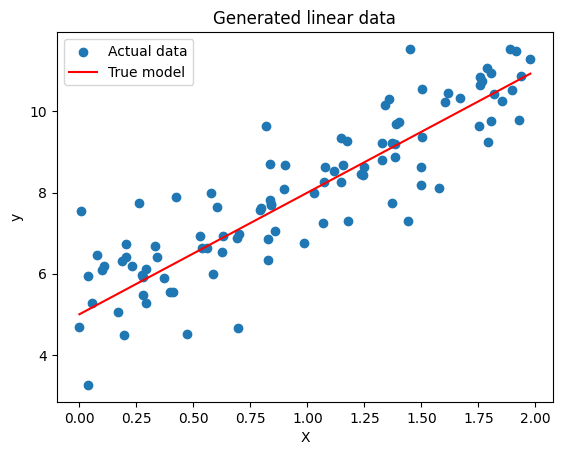

In [14]:
# let's generate some linear-looking data
# the underlying true model is y = 5 + 3x

# fix the random seed so that each run generates the same set of random numbers
np.random.seed(1)
# generate 100 random numbers between 0 and 2 with shape (100, 1)
X = 2 * np.random.rand(100, 1)
# generate 100 random numbers from a normal distribution
#switched to 1000 for a more accurate coefficient because the size of the training set matters
y = 5 + 3 * X + np.random.randn(100, 1)

x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, 5 + 3 * x_grid, color="red", label="True model")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Generated linear data")
ax.legend()
plt.show()

In [15]:
# Use sklearn for linear regression
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()
lr.fit(X, y) # use the normal equation to train the model

LinearRegression()

Documentation page of LinearRegression:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [17]:
# linear regression results using sklearn
# print out the intercept and coefficient(s)

#ran a second time and got much closer to the actual coefficients
print(lr.intercept_, lr.coef_)

[5.23695725] [[2.84246254]]


In [18]:
a0 = lr.intercept_[0]
a1 = lr.coef_[0,0]
print(a0,a1)

5.2369572541489084 2.8424625438276605


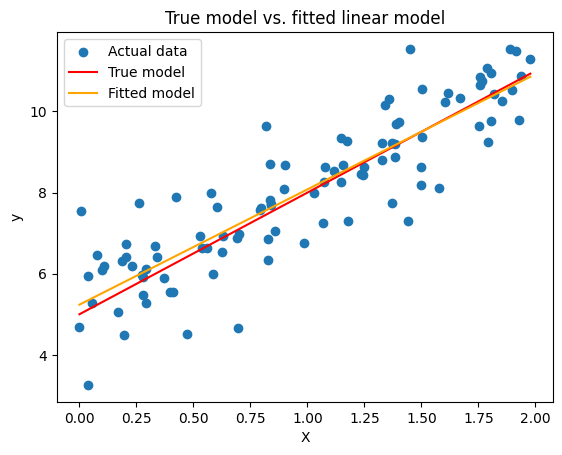

In [19]:
# Plot both the real model and the fitted model in the same graph
fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, 5 + 3 * x_grid, color="red", label="True model")
ax.plot(x_grid, a0 + a1 * x_grid, color="orange", label="Fitted model")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("True model vs. fitted linear model")
ax.legend()
plt.show()

### Making predictions using the model

In [20]:
# making predictions using the model
#use a seperate test set or the training set for predictions
X_new = np.array([[0.6], [0.9], [1.3]])
y_new_pred = lr.predict(X_new)
y_new_pred

array([[6.94243478],
       [7.79517354],
       [8.93215856]])

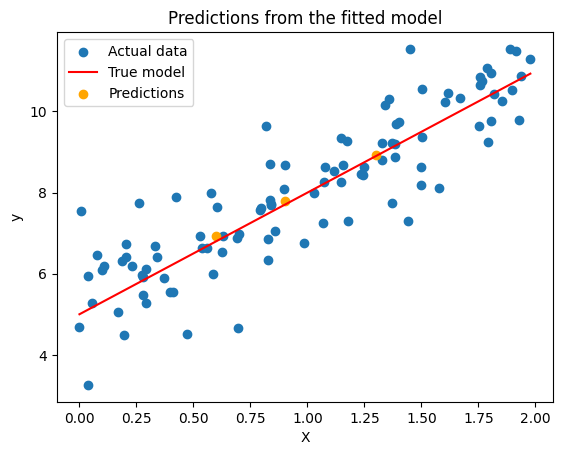

In [21]:
#diagram of the predictions and how they fit into the above chart

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, 5 + 3 * x_grid, color="red", label="True model")
ax.scatter(X_new, y_new_pred, color="orange", label="Predictions")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from the fitted model")
ax.legend()
plt.show()

In [22]:
# Apply the model to X in the training set
y_pred = lr.predict(X)

# calculate MSE and RMSE
# NOTE: the RMSE is measured on the same scale with the same units as y.
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

mse = mean_squared_error(y, y_pred)
print(mse)

rmse = root_mean_squared_error(y, y_pred)
print(rmse)

0.7997618656011584
0.8942940599160649


In [23]:
# R^2 of the model for the training set
# R squared – % of the variance in Y that can be account for or explained by X - fitness metric
lr.score(X, y)

0.7778975321559937

## OLS Regression (optional)

You can do linear regression using `statsmodels` package as follows, which gives you more information (such as R-squared and p-value) from a statistics perspective.

Check out more at: https://dss.princeton.edu/online_help/analysis/interpreting_regression.htm

In [24]:
import statsmodels.api as sm

In [25]:
# if you want to see the p-value, etc. use the following code

X1 = sm.add_constant(X) # Need this line to add a constant (intercept) to the linear model
ols_reg = sm.OLS(y, X1)
res = ols_reg.fit()
print(res.summary())

# exactly same results as sklearn

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     343.2
Date:                Mon, 11 May 2026   Prob (F-statistic):           8.70e-34
Time:                        21:46:44   Log-Likelihood:                -130.72
No. Observations:                 100   AIC:                             265.4
Df Residuals:                      98   BIC:                             270.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2370      0.174     30.041      0.0

## Polynomial Regression

Polynomial Regression can fit non-linear data to a linear model by adding powers of each feature as new features and then train a linear model on the extended set of features.

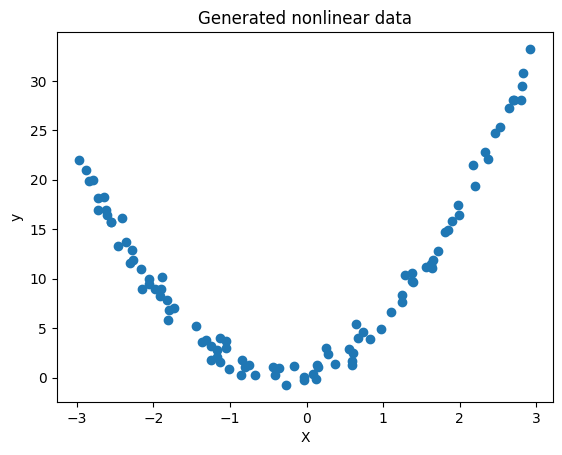

In [26]:
# generate some non-linear data
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 1 + 2* X + 3 * X**2 + np.random.randn(m, 1)  # the "real" function is y = 1 + 2*x + 3*x^2

fig, ax = plt.subplots()
ax.scatter(X, y)
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Generated nonlinear data")
plt.show()

In [27]:
from sklearn.preprocessing import PolynomialFeatures
# a is a column vector representing two features x1, x2
a = np.array([[2, 3, 5], [7, 11, 13] ]).T
print(a)

# degree=2 added x1*x2, x1^2, x2^2
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
b = poly_features_2.fit_transform(a)
print(b)
# degree=3 added x1*x2, x1^2, x2^2, x1^2*2, x2^2*x1, x1^3, x2^3
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
c = poly_features_3.fit_transform(a)
print(c)

#the first two columns are the polynomial terms and the rest are generate by those original features

[[ 2  7]
 [ 3 11]
 [ 5 13]]
[[  2.   7.   4.  14.  49.]
 [  3.  11.   9.  33. 121.]
 [  5.  13.  25.  65. 169.]]
[[2.000e+00 7.000e+00 4.000e+00 1.400e+01 4.900e+01 8.000e+00 2.800e+01
  9.800e+01 3.430e+02]
 [3.000e+00 1.100e+01 9.000e+00 3.300e+01 1.210e+02 2.700e+01 9.900e+01
  3.630e+02 1.331e+03]
 [5.000e+00 1.300e+01 2.500e+01 6.500e+01 1.690e+02 1.250e+02 3.250e+02
  8.450e+02 2.197e+03]]


In [28]:
print(X[:3])

[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]]


In [34]:
# add polynomial features for X in the plot
# function= y = a0 + a1x + a2x^2 + error term
X_poly = poly_features_3.fit_transform(X)
print(X_poly[:3])  # X, X^2

[[-0.75275929  0.56664654 -0.42654845]
 [ 2.70428584  7.3131619  19.77688015]
 [ 1.39196365  1.93756281  2.697017  ]]


In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[0.78437842] [[ 2.02570217  3.06304305 -0.01702965]]


In [36]:
a0 = lin_reg.intercept_[0]
a1 = lin_reg.coef_[0,0]
a2 = lin_reg.coef_[0,1]
print(a0,a1,a2)

0.7843784173216619 2.025702166361613 3.063043048991467


In [37]:
y_pred = a0 + a1*X + a2*X**2

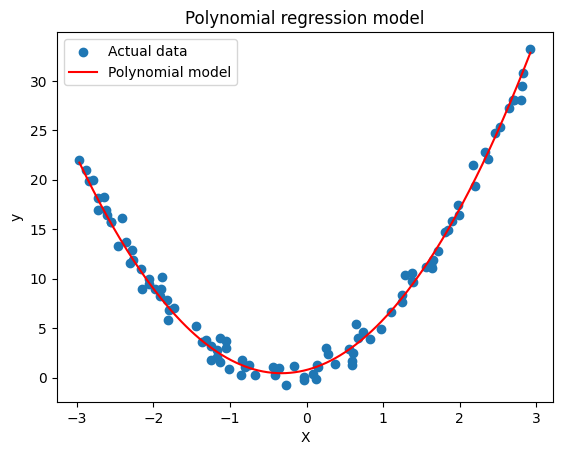

In [38]:
# the "real" function is y = 1 + 2*x + 3*x^2
# the fitted model: y = 0.781 + 1.934*X + 3.065*X^2 - pretty close
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_grid_pred = a0 + a1 * x_grid + a2 * x_grid**2

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, y_grid_pred, color="red", label="Polynomial model")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Polynomial regression model")
ax.legend()
plt.show()

## Log Transformation

Some relationships are nonlinear on the original scale, but become approximately linear after transforming the target variable.

In this example, the true relationship is exponential:

$$y = e^{1 + 2x + \epsilon}$$

Taking the logarithm of `y` gives us an approximately linear relationship:

$$log(y) \approx 1 + 2x$$

Here, we transform the target variable `y`. The predictor `X` stays the same.

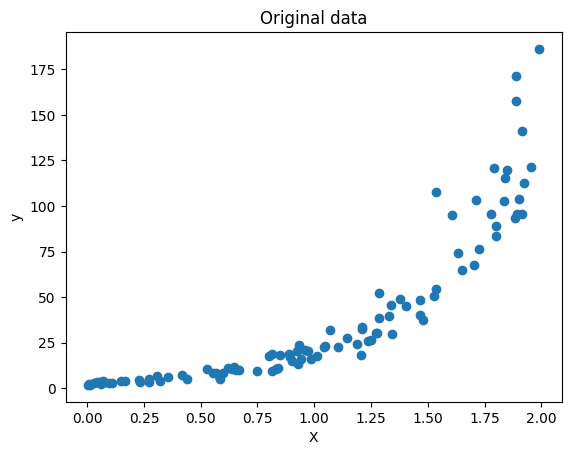

In [39]:
# generate some non-linear data
np.random.seed(12)
m = 100
X = np.random.rand(m, 1) * 2 # generate random numbers between 0 and 2
noise = np.random.randn(m, 1) * 0.2
y = np.exp(1 + 2 * X + noise) # the "real" function is y = e^(1 + 2*x + noise)

fig, ax = plt.subplots()
ax.scatter(X, y)
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Original data")
plt.show()

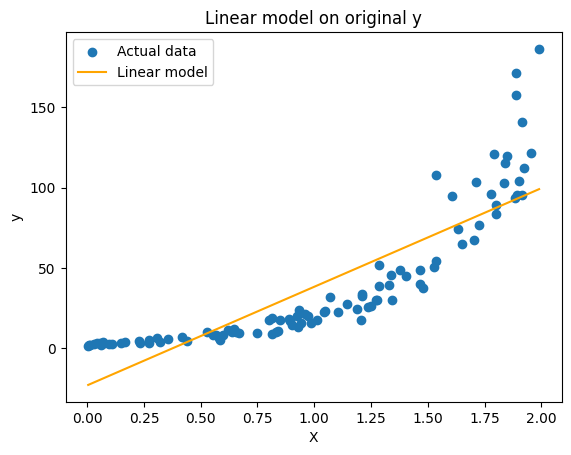

In [40]:
# Fit a regular linear regression model to the original data
linear_model = LinearRegression()
linear_model.fit(X, y)

x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
linear_grid_pred = linear_model.predict(x_grid)

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, linear_grid_pred, color="orange", label="Linear model")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Linear model on original y")
ax.legend()
plt.show()

In [42]:
# Transform the target variable y using log(y)
log_y = np.log(y)

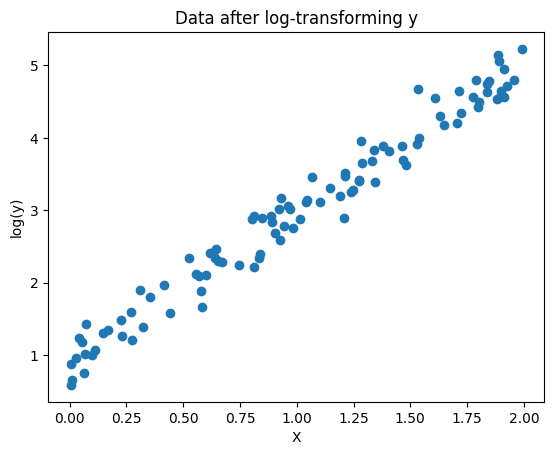

In [43]:
fig, ax = plt.subplots()
ax.scatter(X, log_y)
ax.set_xlabel("X")
ax.set_ylabel("log(y)")
ax.set_title("Data after log-transforming y")
plt.show()

In [44]:
# Fit a linear regression model using X and log_y
log_model = LinearRegression()
log_model.fit(X, log_y)
print(log_model.intercept_, log_model.coef_)

[0.92290221] [[2.04513227]]


In [45]:
a0 = log_model.intercept_[0]
a1 = log_model.coef_[0, 0]
print(a0,a1)

0.9229022089301577 2.0451322663535874


In [46]:
# Predict on the log scale, then transform predictions back to the original y scale
log_grid_pred = log_model.predict(x_grid)
y_pred_log_model = np.exp(log_grid_pred)

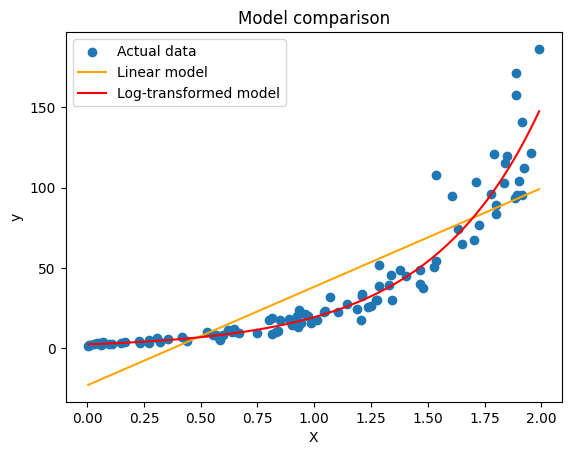

In [47]:
# Compare the regular linear model and the log-transformed model
fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, linear_grid_pred, color="orange", label="Linear model")
ax.plot(x_grid, y_pred_log_model, color="red", label="Log-transformed model")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Model comparison")
ax.legend()
plt.show()

## Exercise: Test your knowledge in regression analysis.

In [48]:
# Read the file "xy.csv"
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/xy.csv')
df

,X,Y
0,8.54,101.83
1,39.70,602.71
2,52.26,2180.25
3,87.44,6873.90
4,74.37,4964.04
...,...,...
195,68.34,3772.20
196,80.40,5388.06
197,51.76,1940.70
198,8.04,-299.61


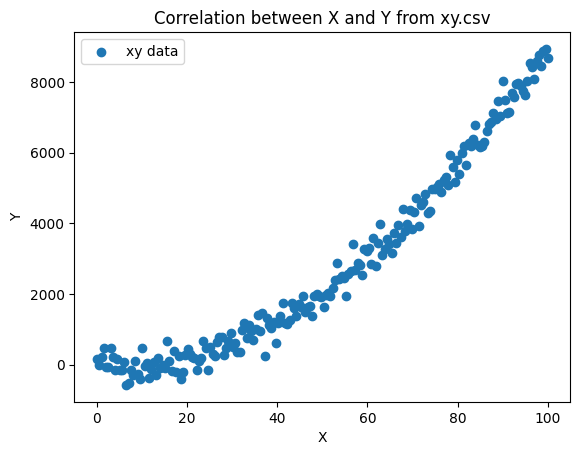

In [49]:
# create a scatter plot to show the correlation between X and Y

fig, ax = plt.subplots()
ax.scatter(df['X'], df['Y'], label="xy data")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Correlation between X and Y from xy.csv")
ax.legend()
plt.show()

In [52]:
# define the independent variable(s) X and dependent variable y
df.head()
X = df [['X']]  #if there is another column to define as X then just add it ex: X = df [['X', 'Z']]
y = df ['Y'] #y is the one depedent variable we want to include (hence the singular pair of brackets)

In [53]:
X.head()

,X
0,8.54
1,39.70
2,52.26
3,87.44
4,74.37


In [54]:
y.head()

,Y
0,101.83
1,602.71
2,2180.25
3,6873.90
4,4964.04


In [57]:
# Build a linear regression model to fit the data

model = LinearRegression()
model.fit(X, y) # use the normal equation to train the model

LinearRegression()

In [61]:
# Calculate the R^2 of the model
model.score(X, y)

0.9160279647198529

In [62]:
y_pred = model.predict(X)

In [63]:
# Calculate the MSE and RMSE of the model
mse = mean_squared_error(y, y_pred)
print(mse)

rmse = root_mean_squared_error(y, y_pred)
print(rmse)

634525.2550612062
796.5709353605655


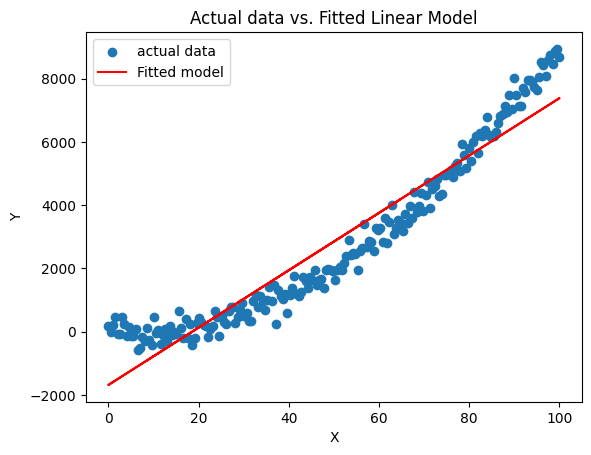

In [64]:
# Plot both the real data and the fitted model in the same chart
# Does the model fit the data well?

fig, ax = plt.subplots()
ax.scatter(X, y, label = "actual data")
ax.plot(X, y_pred, color="red", label="Fitted model")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Actual data vs. Fitted Linear Model")
ax.legend()
plt.show()

In [67]:
# since above doesn't capture the non-linear patterns in the data we must go further
# Now, try to build a new regression model to improve the model fitness.

X_poly = poly_features_2.fit_transform(X)
print(X_poly[:3])

[[   8.54     72.9316]
 [  39.7    1576.09  ]
 [  52.26   2731.1076]]


In [68]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [69]:
# Calculate the R^2 of the model
model.score(X_poly, y)

0.9897840481723319

In [71]:
y_pred = model.predict(X_poly)

In [72]:
# Calculate the MSE and RMSE of the model
mse = mean_squared_error(y, y_pred)
print(mse)

rmse = root_mean_squared_error(y, y_pred)
print(rmse)

77195.6927984177
277.8411287020295


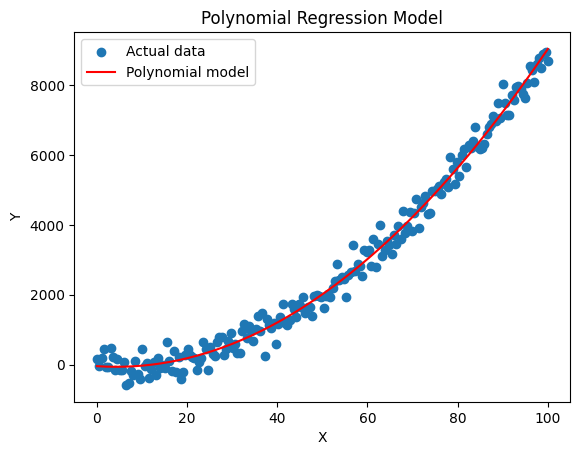

In [73]:
#plot the above X_poly model as a scatterplot with a trend line
#gemini helped me smooth the trend line

# Create a smooth range of X values for plotting the trend line
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# Transform the x_grid into polynomial features
x_grid_poly = poly_features_2.fit_transform(x_grid)

# Predict y values for the x_grid using the trained polynomial model
y_grid_pred = model.predict(x_grid_poly)

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, y_grid_pred, color="red", label="Polynomial model")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Polynomial Regression Model")
ax.legend()
plt.show()

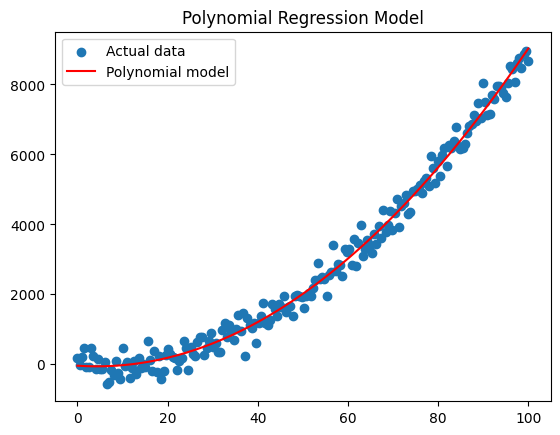

In [75]:
#same as above but the first line is from previous example
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
x_grid_poly = poly_features_2.fit_transform(x_grid)
y_pred = model.predict(x_grid_poly)

fig, ax = plt.subplots()
ax.scatter(X, y, label="Actual data")
ax.plot(x_grid, y_grid_pred, color="red", label="Polynomial model")
ax.set_title("Polynomial Regression Model")
ax.legend()
plt.show()